In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [121]:
full_df = pd.read_csv("umn_apartment_data.csv")

df = full_df.iloc[:,:9]
amenities_df = full_df.iloc[:,9:]

temp_df = pd.DataFrame()
for index, values in amenities_df.iterrows():
    my_list = [values.unique()[:-1]]
    temp_df = pd.concat([temp_df, pd.Series(my_list)], ignore_index = True)

df = pd.concat([df, temp_df], axis = 1, ignore_index = True)

column_list = ["Name", "Address", "Floor Plan", "Bedrooms", "Bathrooms", "Price", "Size", "Availability", "Link", "Amenities"]
column_dic = {}
for i in range(len(column_list)):
    column_dic[df.columns.values[i]] = column_list[i]

df = df.rename(columns = column_dic)

Potential Features:
- Location (Distance from a Central Point)
- Amount of Bathrooms/Beds
- Price
- Size
- Amenities (Specific ID for Each Kind)
- Shaping (potentially)

In [122]:
idx = 0
for value in df["Bedrooms"]:
    if value == "Studio":
        df.iloc[idx, 3] = "0"
    else:
        df.iloc[idx, 3] = value[0]
    idx += 1

idx = 0
for value in df["Price"]:
    end_id = value.find("-")
    try:
        df.iloc[idx, 5] = pd.to_numeric(value[1:end_id])
    except:
        df.iloc[idx, 5] = None
    idx += 1

# idx = 0
# for value in df["Size"]:
#     if type(value) is str:
#         end_id = value.find("-") + 1
#     try:
#         df.iloc[idx, 6] = pd.to_numeric(value[1:end_id])
#     except:
#         df.iloc[idx, 6] = None
#     idx += 1

In [123]:
df["Size"].unique()

array(['1239', '1035', '806', nan, '1180', '1227', '1136', '1192', '1197',
       '1020', '1065', '1028', '798', '789', '553', '635', '668', '510',
       '500', '0', '850', '750', '600', '725', '862', '1200', '1348',
       '1282', '1374', '615', '488', '1715', '1732', '578', '562', '442',
       '1596', '1657', '959', '870', '884', '948', '1000', '1071', '630',
       '677', '779', '509', '480', '1626', '1491', '1110', '1135', '1022',
       '1063', '954', '965', '971', '1005', '1009', '1107', '670', '684',
       '663', '753', '755', '490', '531', '560', '561', '1261', '987',
       '1220', '1185', '1270', '1013', '1650', '1600', '1250', '1550',
       '602', '703', '642', '650', '400', '1100', '900', '800', '555',
       '446', '1133', '1314', '1380', '1457', '1047', '1116', '1153',
       '994', '882', '486', '859', '1255', '1390', '1230', '1304', '1208',
       '1338', '847', '515', '402', '417', '1057', '756', '843', '995',
       '853', '886', '910', '865', '975', '803', '917',

Text(0, 0.5, 'Size')

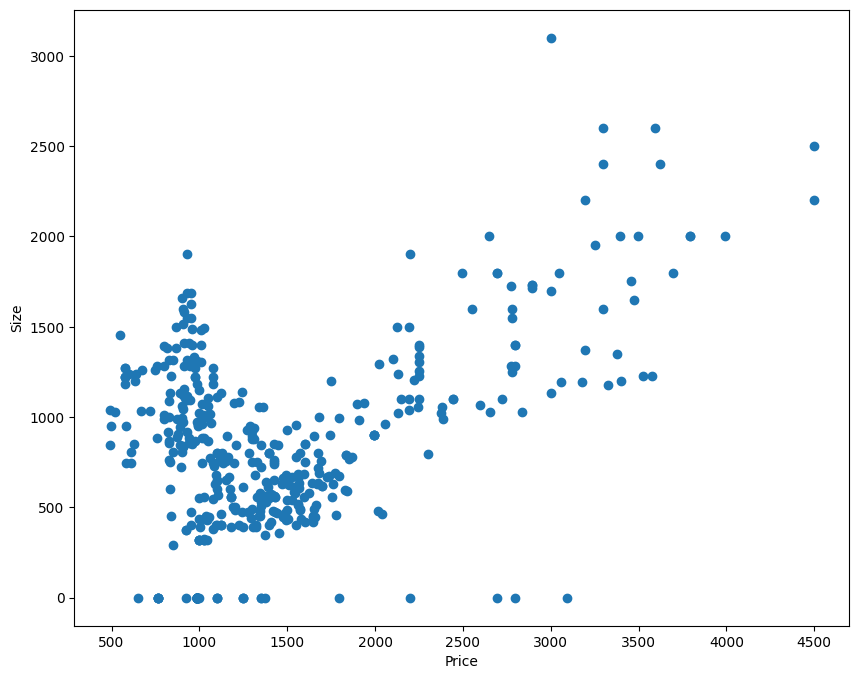

In [25]:
gs, ax = plt.subplots(figsize = (10,8))

plt.scatter(df.sort_values("Price")["Price"], df.sort_values("Price")["Size"])

plt.xlabel("Price")
plt.ylabel("Size")


In [19]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
df['Bathrooms'] = pd.to_numeric(df['Bathrooms'], errors='coerce')
df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce')
df = df.dropna()

In [21]:
print(df[["Price", "Size", "Bathrooms", "Bedrooms"]].corr())

              Price      Size  Bathrooms  Bedrooms
Price      1.000000  0.494084   0.162138  0.510139
Size       0.494084  1.000000   0.685443  0.777038
Bathrooms  0.162138  0.685443   1.000000  0.756518
Bedrooms   0.510139  0.777038   0.756518  1.000000


In [88]:
full_house_df = pd.read_csv("umn_housing_data.csv")

In [89]:
house_df = full_house_df.iloc[:,:7]
house_amenities_df = full_house_df.iloc[:,7:]
house_amenities_df

temp_df = pd.DataFrame()
for index, values in house_amenities_df.iterrows():
    my_list = [values.unique()[:-1]]
    temp_df = pd.concat([temp_df, pd.Series(my_list)], ignore_index = True)

house_df = pd.concat([house_df, temp_df], axis = 1, ignore_index = True)

column_list = ["Address", "Name", "Bedrooms", "Bathrooms", "Price", "Size", "Availability", "Amenities"]
column_dic = {}
for i in range(len(column_list)):
    column_dic[house_df.columns.values[i]] = column_list[i]

house_df = house_df.rename(columns = column_dic)
house_df



,Address,Name,Bedrooms,Bathrooms,Price,Size,Availability,Amenities
0,609 15th Ave SE Minneapolis MN 55414,#101,4,3.0,$3300.00,NaN,09-01-2026,"[9 Foot Ceilings, Dishwasher, Oven, Refrigerat..."
1,609 15th Ave SE Minneapolis MN 55414,#201,4,4.0,$3300.00,NaN,09-01-2026,"[9 Foot Ceilings, Dishwasher, Oven, Refrigerat..."
2,609 15th Ave SE Minneapolis MN 55414,#301,4,4.0,$3300.00,NaN,09-01-2026,"[9 Foot Ceilings, Dishwasher, Oven, Refrigerat..."
3,609 15th Ave SE Minneapolis MN 55414,#401,4,4.0,$3300.00,NaN,09-01-2026,"[9 Foot Ceilings, Dishwasher, Oven, Refrigerat..."
4,1021 24th Ave SE Minneapolis MN 55414 USA,NaN,3,1.0,$1850.00,NaN,09-03-2026,[]
...,...,...,...,...,...,...,...,...
128,1205 Talmage Ave SE Minneapolis MN 55414,UNIT 3,6,3.0,$3695.00,NaN,09-01-2026,"[Air Conditioning, 24 Hour Emergency Maintenance]"
129,1012 8th St SE Minneapolis MN 55414 United States,2,5,2.0,$3250.00,1500.0,09-01-2026,"[Air Conditioning, Bedrooms Keyed Separately, ..."
130,711 5th Ave SE Minneapolis MN 55414 USA,NaN,5,2.0,$3000.00,NaN,09-03-2026,[]
131,1319 7th St SE Minneapolis MN 55414 United States,1321,7,2.0,$4650.00,NaN,09-01-2026,"[Hardwood Floors, Oven, Porch, Private Balcony..."


In [1]:
idx = 0
for value in house_df["Price"]:
    end_id = value.find("-")
    try:
        house_df.iloc[idx, 4] = pd.to_numeric(value[1:end_id])
    except:
        house_df.iloc[idx, 4] = None
    idx += 1

NameError: name 'house_df' is not defined